In [108]:
import configparser
from pathlib import Path

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import distance
from sklearn.model_selection import train_test_split
import torch
from torch import optim, Tensor
from torch.nn import Module
from torch.utils.data import DataLoader
from tqdm import tqdm
import gc
import gzip
import nibabel as nib   
import model_dr_unet
import shutil
from scipy.ndimage import zoom
import model_unet

In [109]:
class TqdmExtraFormat(tqdm):
    @property
    def format_dict(self):
        d = super(TqdmExtraFormat, self).format_dict
        total_time = d["elapsed"] * (d["total"] or 0) / max(d["n"], 1)
        d.update(total_time=self.format_interval(total_time))
        return d

In [110]:
def plot(img, mask_true, mask_pred, idx):
    img = np.squeeze(img, axis=1)
    mask_true = np.squeeze(mask_true, axis=1)
    mask_pred = np.squeeze(mask_pred, axis=1)
    max_value = img.max()
    if max_value > 0:
        img = img / max_value
    else:
        img = img.copy()

    num_slice = img.shape[0]
    fig, axs = plt.subplots(num_slice, 3, squeeze=False)
    axs: list[list[plt.Axes]]
    for i in range(num_slice):
        axs[i][0].imshow(img[i], cmap='gray')
        axs[i][0].set_title(f'z = {i}')
        axs[i][1].imshow(mask_true[i], cmap='gray')
        axs[i][1].set_title(f'ID {idx:03d}\nGround truth')
        axs[i][2].imshow(mask_pred[i], cmap='gray')
        axs[i][2].set_title('AI generated')
    for i in range(num_slice):
        for j in range(3):
            axs[i][j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    return fig

In [111]:
from pathlib import Path

import nibabel as nib

class SliceDataset:
    def __init__(self, img_paths: Path, mask_paths: Path, intensity_min, intensity_max) -> None:
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.slices = [nib.load(p).shape[-1] for p in self.img_paths]
        self.cum_slices = np.cumsum(self.slices)
        self.intensity_min = intensity_min
        self.intensity_max = intensity_max

    def __getitem__(self, index: int):
        path_index = np.searchsorted(self.cum_slices, index, side='right')
        if path_index == 0:
            slice_index = index
        else:
            slice_index = index - self.cum_slices[path_index - 1]

        zoom_factors = (256/240, 256/240)

        mask = nib.load(self.mask_paths[path_index]).get_fdata()[:,:,slice_index]
        mask = zoom(mask, zoom_factors, order=0)
        assert mask.shape == (256, 256), "Resized image shape does not match desired shape"
        mask = mask[np.newaxis, ...]

        img = nib.load(self.img_paths[path_index]).get_fdata()[:,:,slice_index]
        img = zoom(img, zoom_factors, order=1)
        assert img.shape == (256, 256), "Resized image shape does not match desired shape"
        img = windowing(img, self.intensity_min, self.intensity_max)[np.newaxis, ...]
        
        return img.astype(np.float32), mask.astype(np.float32)
    
    def filter_samples(self, index):
        # Check if the sum of the mask for the given index is greater than 0
        path_index = np.searchsorted(self.cum_slices, index, side='right')
        if path_index == 0:
            slice_index = index
        else:
            slice_index = index - self.cum_slices[path_index - 1]

        mask = nib.load(self.mask_paths[path_index]).get_fdata()[:,:,slice_index]
        return np.sum(mask) > 0 # returns true if mask has values
    
    def __len__(self):
        return self.cum_slices[-1]

def windowing(image, min_value, max_value):
    image_new = np.clip(image, min_value, max_value)
    image_new = (image_new - min_value) / (max_value - min_value)
    return image_new

class Subset(SliceDataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]

In [120]:
def train_epoch(config: configparser.ConfigParser, loader: DataLoader, model: Module, optimizer: optim.Adam):
    print(f'length of train loader = {len(loader)}')
    model.train()
    device = config['train']['device']
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    debug = False 

    loss_values = list()
    
    with tqdm(total=len(loader)) as pbar:
        for batch_idx, sample in enumerate(loader):
            sample: tuple[Tensor, ...]
            img, mask_true = sample
            model_output = model(img.to(device)) 
             
            mask_pred = model_output.float().to(device).requires_grad_()
            mask_true = (mask_true == 1).float().to(device).requires_grad_()

            intersection = torch.sum(mask_pred * mask_true)
            union = torch.sum(mask_pred) + torch.sum(mask_true)
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            loss = 1. - dice
            
            optimizer.zero_grad()
            loss.backward()
            loss_values.append(loss.item())
            optimizer.step()
            
            pbar.update()
            if debug and batch_idx == 1:
                break

    torch.save(model.state_dict(), Path(config['train']['save_path']) / "temp_model_weights.pth")

    pbar.close()
    print(f'loss = {np.mean(loss_values)} ± {np.std(loss_values)}')

In [113]:
def val_epoch(config: configparser.ConfigParser, loader: DataLoader, model: Module, scheduler: optim.lr_scheduler.ReduceLROnPlateau):
    print(f'length of validation loader = {len(loader)}')
    model.eval()
    device = config['train']['device']
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    debug = config['train'].getboolean('debug')
    weights_save_path = Path(config['train']['save_path']) / 'model_weights.pth'
    val_metrics_path = Path(config['train']['save_path']) / 'val_metrics.txt'
    new_metrics = []
    pdf = PdfPages(Path(config['train']['save_path']) / 'val_figures.pdf')

    if not val_metrics_path.is_file():
        old_metrics = [0]
    else:
        old_metrics = np.loadtxt(val_metrics_path)
    
    with tqdm(total=len(loader)) as pbar:
        for idx, sample in enumerate(loader):
            sample: tuple[Tensor, ...]
            img, mask_true = sample
            
            model_output = model(img.to(device))
            mask_pred = model_output.cpu().detach().numpy()
            mask_true = (mask_true == 1).numpy()
            dice = 1 - distance.dice(mask_pred.reshape(-1), mask_true.reshape(-1))
            new_metrics.append(dice)
            pbar.update()

            fig = plot(img.numpy(), mask_true, mask_pred, idx)
            fig.set_size_inches(15, 5 * mask_true.shape[0])
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()

            if debug and idx == 1:
                break

    pbar.close()
    pdf.close()
    
    print(f'dice = {np.mean(new_metrics)} ± {np.std(new_metrics)}')
    
    if np.mean(new_metrics) > np.mean(old_metrics) or not weights_save_path.is_file():
        print("Performance improved, saving new weights.")
        torch.save(model.state_dict(), config['train']['save_path'] / 'model_weights.pth')
        np.savetxt(val_metrics_path, new_metrics, fmt='%.5f')

    scheduler.step(np.mean(new_metrics))    

In [114]:
def train(config: configparser.ConfigParser):
    print('Training...')

    mri_scans = sorted(Path(config['train']['imgs_train_val']).glob("TCGA*"))
    img_train_val_paths = []
    mask_train_val_paths = []
    debug = config['train'].getboolean('debug')

    for mri_scan in mri_scans:
        flair_img = sorted(Path(mri_scan).glob("*_flair.nii.gz"))
        if len(flair_img) == 0:
            continue
        else:
            flair_img = flair_img[0]
        mask_imgs = sorted(Path(mri_scan).glob("*GlistrBoost_ManuallyCorrected.nii.gz"))
        if len(mask_imgs) == 0:
            mask_img = sorted(Path(mri_scan).glob("*_GlistrBoost.nii.gz"))[0]
        else:
            mask_img = mask_imgs[0]

        with gzip.open(flair_img, 'rb') as f_in:
            with open(Path(mri_scan) / "flair.nii", 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        with gzip.open(mask_img, 'rb') as f_in:
            with open(Path(mri_scan) / "mask.nii", 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

        img_train_val_paths.append(Path(mri_scan) / "flair.nii")
        mask_train_val_paths.append(Path(mri_scan) / "mask.nii")

    print(f'len(img_train_val_paths) = {len(img_train_val_paths)}')
    print(f'len(mask_train_val_paths) = {len(mask_train_val_paths)}')

    train_size = config['train'].getfloat('train_size')
    random_seed = config['train'].getint('random_seed')

    img_train_paths, img_val_paths, mask_train_paths, mask_val_paths = train_test_split(
        img_train_val_paths, mask_train_val_paths, train_size=train_size, random_state=random_seed
    )

    print(f'len(img_train_paths) = {len(img_train_paths)}')
    print(f'len(img_val_paths) = {len(img_val_paths)}')
    print(f'len(mask_train_paths) = {len(mask_train_paths)}')
    print(f'len(mask_val_paths) = {len(mask_val_paths)}')

    intensity_min = config['train'].getint('intensity_min')
    intensity_max = config['train'].getint('intensity_max')
    trainset = SliceDataset(img_train_paths, mask_train_paths, intensity_min, intensity_max)
    valset = SliceDataset(img_val_paths, mask_val_paths, intensity_min, intensity_max)
    print(f'len(trainset) = {len(trainset)}')
    print(f'len(valset) = {len(valset)}')
    
    with tqdm(total=len(trainset) + len(valset), desc='Filtering datasets') as pbar:
        train_indices = []
        for train_idx in range(len(trainset)):
            if trainset.filter_samples(train_idx):
                train_indices.append(train_idx)
            pbar.update(1)

            if debug and train_idx == 200:
                break
                    
        val_indices = []
        for val_idx in range(len(valset)):
            if valset.filter_samples(val_idx):
                val_indices.append(val_idx)
            pbar.update(1)

            if debug and val_idx == 100:
                break

        filtered_trainset = Subset(trainset, train_indices)
        filtered_valset = Subset(valset, val_indices)    
    pbar.close()

    print(f'len(filtered_trainset) = {len(filtered_trainset)}')
    print(f'len(filtered_valset) = {len(filtered_valset)}')

    trainloader = DataLoader(filtered_trainset, batch_size=8, shuffle=True, num_workers=0)
    valloader = DataLoader(filtered_valset, batch_size=8, shuffle=True, num_workers=0)

    print(f'len(trainloader) = {len(trainloader)}')
    print(f'len(valloader) = {len(valloader)}')

    # Change which model you want to use here
    # model_class = getattr(model_dr_unet, "DRUNet")
    model_class = getattr(model_unet, "U_Net")
    #model_class = getattr(model_dense_unet, "Dense_Net")
    model = model_class()
    
    print(f'model.__class__.__name__ = {model.__class__.__name__}')
    print()

    device = config['train']['device']
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # This is needed to run gpus on mac
    model.to(device)

    optimizer = optim.Adam(model.parameters())
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=1 / 10 ** .5, patience=2)

    val_metrics = Path(config['train']['val_metrics'] + '/val_metrics.txt')
    if val_metrics.is_file():
        val_metrics.unlink()

    for epoch in range(1, 15):
        if Path(config['train']['save_path'] + '/temp_model_weights.pth').is_file():
            model.load_state_dict(torch.load(config['train']['save_path'] + '/temp_model_weights.pth'))
        print(f'epoch = {epoch:03d}')

        train_epoch(config, trainloader, model, optimizer)
        torch.cuda.empty_cache()

        val_epoch(config, valloader, model, scheduler)
        torch.cuda.empty_cache()
        print()

        if debug and epoch == 2:
            break
        if optimizer.param_groups[0]['lr'] < 1e-6:
            break

In [122]:
def test(config: configparser.ConfigParser):
    print('Testing...')

    mri_scans_test = sorted(Path(config['test']['imgs_test']).glob("TCGA*"))
    img_test_paths = []
    mask_test_paths = []
    weights_path = Path(config['test']['save_path'] + '/model_weights.pth')
    debug = config['test'].getboolean('debug')

    for mri_scan in mri_scans_test:
        flair_img = sorted(Path(mri_scan).glob("flair.nii"))[0]
        mask_img = sorted(Path(mri_scan).glob("mask.nii"))[0]
        if flair_img is None or mask_img is None:
            continue

        img_test_paths.append(Path(mri_scan) / "flair.nii")
        mask_test_paths.append(Path(mri_scan) / "mask.nii")

    print(f'len(img_test_paths) = {len(img_test_paths)}')
    print(f'len(mask_test_paths) = {len(mask_test_paths)}')

    intensity_min = config['train'].getint('intensity_min')
    intensity_max = config['train'].getint('intensity_max')

    testset = SliceDataset(img_test_paths, mask_test_paths, intensity_min, intensity_max)
    print(f'len(testset) = {len(testset)}')
    
    with tqdm(total=len(testset), desc='Filtering datasets') as pbar:
        test_indices = []
        for test_idx in range(len(testset)):
            if testset.filter_samples(test_idx):
                test_indices.append(test_idx)
            pbar.update(1)

            if debug and test_idx == 10:
                break
                    
        filtered_testset = Subset(testset, test_indices)
    pbar.close()

    print(f'len(filtered_testset) = {len(filtered_testset)}')

    testloader = DataLoader(filtered_testset, batch_size=8, shuffle=False, num_workers=0)
    print(f'len(testloader) = {len(testloader)}')
        
    #model_class = getattr(model_dr_unet, "DRUNet")
    model_class = getattr(model_unet, "U_Net")
    #model_class = getattr(model_dense_unet, "Dense_Net")
    model = model_class()
    
    print(f'model.__class__.__name__ = {model.__class__.__name__}')
    print()
    
    model.load_state_dict(torch.load(weights_path))
    device = config['train']['device']
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)
    
    test_metrics_path = Path(config['test']['test_metrics'])
    new_metrics = []
    try:
        with PdfPages(Path(config['test']['save_path']) / 'test_figures.pdf') as pdf:
            with torch.no_grad(), tqdm(total=len(testloader)) as pbar:
                for idx, sample in enumerate(testloader):
                    sample: tuple[Tensor, ...]
                    img, mask_true = sample
                
                    model_output = model(img.to(device))
                    mask_pred = model_output.detach().cpu().numpy()
                    mask_true = (mask_true == 1).numpy()
                    dice = 1 - distance.dice(mask_pred.reshape(-1), mask_true.reshape(-1))
                    new_metrics.append(dice)
                    pbar.update()

                    fig = plot(img.numpy(), mask_true, mask_pred, idx)
                    fig.set_size_inches(15, 5 * mask_true.shape[0])
                    pdf.savefig(fig, bbox_inches='tight')
                    plt.close(fig)

                    if debug and idx == 1:
                        break
            pbar.close()
    except Exception as e:
        print(f"Error during PDF generation: {e}")
        raise
        
    print(new_metrics)
    np.savetxt(test_metrics_path, new_metrics, fmt='%.5f')

In [116]:
config = configparser.ConfigParser()
config.read('/Users/sarahmialiu/Documents/Image Analysis Fall 2025/Final Project/config.ini')
train(config)

Training...
len(img_train_val_paths) = 92
len(mask_train_val_paths) = 92
len(img_train_paths) = 82
len(img_val_paths) = 10
len(mask_train_paths) = 82
len(mask_val_paths) = 10
len(trainset) = 12710
len(valset) = 1550


Filtering datasets:   2%|▏         | 302/14260 [00:02<01:37, 143.77it/s]


len(filtered_trainset) = 67
len(filtered_valset) = 27
len(trainloader) = 9
len(valloader) = 4
model.__class__.__name__ = U_Net

epoch = 001
length of train loader = 9


100%|██████████| 9/9 [00:09<00:00,  1.05s/it]


loss = 0.9969165921211243 ± 0.0016351379520331555
length of validation loader = 4


...

dice = 0.0025080902281761075 ± 0.0021886223387173054

epoch = 002
length of train loader = 9


100%|██████████| 9/9 [00:08<00:00,  1.04it/s]


loss = 0.9963431292110019 ± 0.0043575010743449275
length of validation loader = 4


 50%|█████     | 2/4 [00:02<00:02,  1.40s/it]

dice = 0.002427441824715937 ± 0.0014125410091591628



In [124]:
config = configparser.ConfigParser()
config.read('/Users/sarahmialiu/Documents/Image Analysis Fall 2025/Final Project/config.ini')
test(config)

Testing...
len(img_test_paths) = 2
len(mask_test_paths) = 2
len(testset) = 310


Filtering datasets: 100%|██████████| 310/310 [00:02<00:00, 151.85it/s]


len(filtered_testset) = 131
len(testloader) = 17
model.__class__.__name__ = U_Net



100%|██████████| 17/17 [00:17<00:00,  1.05s/it]


[0.002317330838930043, 0.0656946892898076, 0.09937305911155114, 0.11319505673063801, 0.07836050457157917, 0.05775903435391461, 0.00011745773891091993, 0.0, 0.0, 0.0, 0.004848829072418903, 0.007375149026531136, 0.00882354751125547, 0.0131211877724009, 0.0015780913604158675, 6.113592986300986e-05, 0.0]


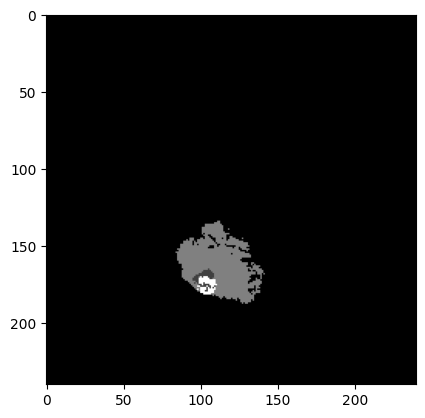

In [ ]:
## VIEW SAMPLE GROUND TRUTH MASK
img = nib.load("/Users/sarahmialiu/Documents/Image Analysis Fall 2025/Final Project/PKG - BraTS-TCGA-GBM/BraTS-TCGA-GBM/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-02-0006/TCGA-02-0006_1996.08.23_GlistrBoost.nii")
plt.imshow(img.get_fdata()[:,:,45], cmap='gray')

(240, 240, 155)

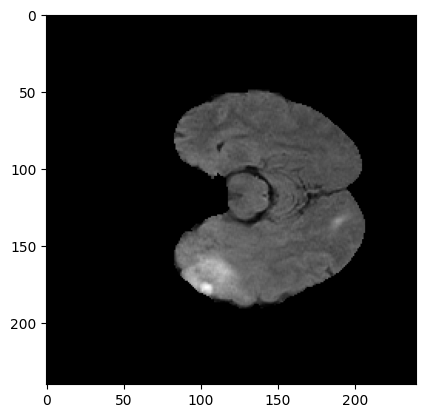

In [ ]:
# VIEW SAMPLE MRI IMAGE
a = sorted(Path("/Users/sarahmialiu/Documents/Image Analysis Fall 2025/Final Project/PKG - BraTS-TCGA-GBM/BraTS-TCGA-GBM/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations").glob("TCGA*"))
img = nib.load(Path(a[0]) / "flair.nii")
plt.imshow(img.get_fdata()[:,:,45], cmap='gray')
img.shape